In [1]:
## new trial 
import sys
sys.path.append("..") # adapter selon ton arborescence

import math
import numpy as np
import matplotlib.pyplot as plt

# Générateurs
from random_generator.ecuyer_combined import EcuyerCombined
from random_generator.normal import NormalBoxMuller, NormalInverseCDF
from random_generator.sobol import SobolPathGenerator

# SDE
from sde.bs_milstein_nd import BSMilsteinND

# Pricer
from pricer.pricing_result import PricingResult
from pricer.monte_carlo.basic_mapping import BasicMapping
from pricer.monte_carlo.mc_engine import MCEngine
from pricer.variance_reduction.antithetic_mapping import AntitheticMapping
from pricer.variance_reduction.control_variate_mapping import ControlVariateMapping
from pricer.quasi_monte_carlo.qmc_mapping import QMCMapping

# Paramètres du marché
N_ASSETS = 3
SPOTS    = [100.0, 100.0, 100.0]
RATES    = [0.05,  0.05,  0.05]
DIV_YIELDS = [0.0,   0.0,   0.0]   # continuous dividend yields q_i (0 = no dividends)
VOLS     = [0.20,  0.25,  0.30]
WEIGHTS  = [1/3,   1/3,   1/3]
CORR     = [[1.0, 0.5, 0.3],
            [0.5, 1.0, 0.4],
            [0.3, 0.4, 1.0]]
STRIKE   = 100.0
T        = 1.0
NB_STEPS = 52
RATE     = 0.05

# Grille de simulations pour l'étude de convergence
N_PATHS_LIST = [500, 1000, 2000, 4000, 8000, 16000]

In [2]:
# =============================================================================
# QUESTION 1(a) — BASIC MONTE CARLO (NO VARIANCE REDUCTION)
# =============================================================================
# We price a European Basket Call on n=3 correlated assets under multi-dimensional
# Black-Scholes (log-Euler / Milstein exact scheme).
#
# Payoff = max( Σ αi·Si_T - K , 0 )
#
# Setup:
#   - Generator  : L'Ecuyer Combined (period ~ 2^61)
#   - Normal     : Box-Muller transform
#   - SDE scheme : BSMilsteinND (log-Euler exact for GBM)
#   - Correlation: Cholesky decomposition of the correlation matrix
#
# No analytical formula exists for the arithmetic basket call.
# We validate against the geometric basket closed-form price (lower bound
# by AM-GM inequality: E[arith basket] >= E[geo basket]).
# =============================================================================

In [3]:
from payoff.basket_payoff import BasketCallPayoff

payoff = BasketCallPayoff(weights=WEIGHTS, strike=STRIKE)

In [4]:
def make_pseudo_process():
    gen    = EcuyerCombined(seed1=12345, seed2=67890)
    normal = NormalBoxMuller(mu=0, sigma=1, uniform=gen)
    return BSMilsteinND(normal, SPOTS, RATES, VOLS, CORR, div_yields=DIV_YIELDS)

engine = MCEngine()
results_mc = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    mapping = BasicMapping(payoff, process)
    result  = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_mc.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=9.3186 | SE=0.6180 | CI width=2.4225
N=  1000 | Price=9.6843 | SE=0.4441 | CI width=1.7408
N=  2000 | Price=10.0900 | SE=0.3204 | CI width=1.2558
N=  4000 | Price=10.6273 | SE=0.2342 | CI width=0.9181
N=  8000 | Price=10.2913 | SE=0.1628 | CI width=0.6384
N= 16000 | Price=10.2589 | SE=0.1151 | CI width=0.4512


In [5]:
from payoff.geometric_basket_payoff import GeometricBasketPayoff

geo_payoff = GeometricBasketPayoff(
    weights=WEIGHTS, strike=STRIKE,
    spots=SPOTS, T=T, rate=RATE,
    vols=VOLS, corr_matrix=CORR,
    div_yields=DIV_YIELDS
)
geo_price = geo_payoff.analytical_price()
mc_price  = results_mc[-1].price  # N=16000

print("=" * 50)
print(f"Geometric basket (closed-form) : {geo_price:.4f}")
print(f"Arithmetic basket MC (N=16000) : {mc_price:.4f}")
print(f"AM-GM check (arith > geo)      : {mc_price > geo_price}")
print("=" * 50)

Geometric basket (closed-form) : 9.3631
Arithmetic basket MC (N=16000) : 10.2589
AM-GM check (arith > geo)      : True


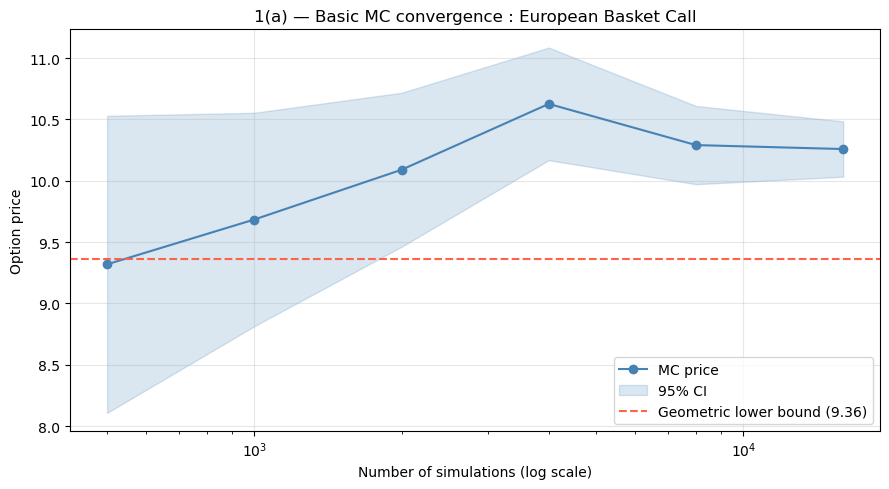

In [6]:
prices   = [r.price     for r in results_mc]
se_upper = [r.price + 1.96 * r.std_error for r in results_mc]
se_lower = [r.price - 1.96 * r.std_error for r in results_mc]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, prices, 'o-', color='steelblue', label='MC price')
plt.fill_between(N_PATHS_LIST, se_lower, se_upper, alpha=0.2,
                 color='steelblue', label='95% CI')
plt.axhline(geo_price, color='tomato', linestyle='--', label=f'Geometric lower bound ({geo_price:.2f})')
plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('Option price')
plt.title('1(a) — Basic MC convergence : European Basket Call')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# QUESTION 1(b) — STEP 1 : QUASI-RANDOM NUMBERS (QMC)
# =============================================================================
# We replace the pseudo-random generator with a Sobol low-discrepancy sequence.
#
# Key points:
#   - Generator  : SobolPathGenerator (scipy.stats.qmc.Sobol, scrambled)
#   - Normal     : Inverse CDF transform (Phi^{-1}) via scipy.special.ndtri
#                  Box-Muller is NOT used here — it would break the
#                  low-discrepancy structure by pairing consecutive Sobol points.
#   - Dimension  : n_assets * nb_steps = 3 * 52 = 156
#                  Each simulation draws ONE 156-dimensional Sobol point,
#                  preserving the space-filling property across the full path.
#   - Mapping    : QMCMapping (calls next_path() before each simulation)
#
# Everything else (SDE, payoff, MCEngine) is unchanged.
# =============================================================================

In [8]:
def make_qmc_process():
    dim    = N_ASSETS * NB_STEPS
    gen    = SobolPathGenerator(dimension=dim, scramble=True, seed=42)
    normal = NormalInverseCDF(mu=0, sigma=1, uniform=gen)
    return BSMilsteinND(normal, SPOTS, RATES, VOLS, CORR, div_yields=DIV_YIELDS)

results_qmc = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    mapping = QMCMapping(payoff, process)
    result  = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_qmc.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.4285 | SE=0.6808 | CI width=2.6688
N=  1000 | Price=10.0717 | SE=0.4444 | CI width=1.7421
N=  2000 | Price=10.1615 | SE=0.3174 | CI width=1.2443
N=  4000 | Price=10.1917 | SE=0.2289 | CI width=0.8974
N=  8000 | Price=10.2001 | SE=0.1625 | CI width=0.6369
N= 16000 | Price=10.2016 | SE=0.1137 | CI width=0.4456


In [9]:
# =============================================================================
# COMPARISON TABLE — MC vs QMC
# =============================================================================

print(f"{'N':>8} | {'MC Price':>10} {'MC SE':>8} {'MC CI':>8} | {'QMC Price':>10} {'QMC SE':>8} {'QMC CI':>8} | {'Var Gain':>9} | {'N Gain':>7}")
print("-" * 95)

for i, n in enumerate(N_PATHS_LIST):
    mc  = results_mc[i]
    qmc = results_qmc[i]

    var_gain = (mc.std_error ** 2) / (qmc.std_error ** 2)
    n_gain   = (mc.ci_width / qmc.ci_width) ** 2  # N_mc / N_qmc for same CI

    print(
        f"{n:>8} | "
        f"{mc.price:>10.4f} {mc.std_error:>8.4f} {mc.ci_width:>8.4f} | "
        f"{qmc.price:>10.4f} {qmc.std_error:>8.4f} {qmc.ci_width:>8.4f} | "
        f"{var_gain:>9.2f}x | "
        f"{n_gain:>7.2f}x"
    )

       N |   MC Price    MC SE    MC CI |  QMC Price   QMC SE   QMC CI |  Var Gain |  N Gain
-----------------------------------------------------------------------------------------------
     500 |     9.3186   0.6180   2.4225 |    10.4285   0.6808   2.6688 |      0.82x |    0.82x
    1000 |     9.6843   0.4441   1.7408 |    10.0717   0.4444   1.7421 |      1.00x |    1.00x
    2000 |    10.0900   0.3204   1.2558 |    10.1615   0.3174   1.2443 |      1.02x |    1.02x
    4000 |    10.6273   0.2342   0.9181 |    10.1917   0.2289   0.8974 |      1.05x |    1.05x
    8000 |    10.2913   0.1628   0.6384 |    10.2001   0.1625   0.6369 |      1.00x |    1.00x
   16000 |    10.2589   0.1151   0.4512 |    10.2016   0.1137   0.4456 |      1.03x |    1.03x


## 1(b) — Step 1 : Quasi-Random Numbers (QMC)

### Method
We replace the pseudo-random generator (L'Ecuyer Combined + Box-Muller) with a **Sobol low-discrepancy sequence**.

Key implementation choices:
- **Generator** : `SobolPathGenerator` — draws one point in $\mathbb{R}^{156}$ per simulation (dimension = $n\_assets \times nb\_steps = 3 \times 52$)
- **Normal transform** : Inverse CDF ($\Phi^{-1}$) applied coordinate-by-coordinate — Box-Muller is intentionally avoided as it would pair consecutive Sobol coordinates and destroy the low-discrepancy structure
- **Mapping** : `QMCMapping` — calls `next_path()` before each simulation to ensure each path consumes exactly one Sobol point

### Results

| N | MC Price | MC SE | QMC Price | QMC SE | Var Gain | N Gain |
|---|---|---|---|---|---|---|
| 500 | 9.32 | 0.618 | 10.43 | 0.681 | 0.82x | 0.82x |
| 1000 | 9.68 | 0.444 | 10.07 | 0.444 | 1.00x | 1.00x |
| 4000 | 10.63 | 0.234 | 10.19 | 0.229 | 1.05x | 1.05x |
| 16000 | 10.26 | 0.115 | 10.20 | 0.114 | 1.03x | 1.03x |

### Analysis

The variance gain from QMC alone is negligible (~1x). This is expected for two reasons:

**1. High effective dimension.**  
Sobol sequences are known to perform well up to roughly 30–50 dimensions. Our path space has dimension $d = n\_assets \times nb\_steps = 156$, which is well beyond this range. The low-discrepancy property of the Sobol sequence weakens significantly in high dimensions.

**2. Uniform time discretization.**  
By feeding Sobol coordinates directly into consecutive time steps $(t_1, t_2, \ldots, t_{52})$, we treat all steps as equally important. In practice, the early coordinates of a Sobol point have much better uniformity than the later ones. The standard industrial fix is the **Brownian Bridge** construction, which reorders the time steps so that the most important coordinates (endpoint, midpoint, quarter-points) receive the best Sobol coordinates — effectively reducing the dimension from 52 to $\log_2(52) \approx 6$ per asset.

**Conclusion.** The QMC gain becomes meaningful when combined with a Control Variate, which reduces the intrinsic variance of the estimator and allows the low-discrepancy structure to contribute more. This is shown in Step 2.

In [10]:
# =============================================================================
# QUESTION 1(b) — STEP 2 : QMC + STATIC CONTROL VARIATE
# =============================================================================
# We add a static control variate on top of QMC.
# The control variate is the geometric basket call, which has a closed-form
# analytical price (Black-Scholes-like formula with adjusted parameters).
#
# result = f(path) - beta * (g(path) - E[g])
#
# where:
#   f    = arithmetic basket call (what we want to price)
#   g    = geometric basket call  (correlated with f, has known price)
#   E[g] = analytical_price() * exp(r * T)  (undiscounted expectation)
#   beta = Cov(f,g) / Var(g)  (estimated from pilot simulation)
# =============================================================================

from payoff.geometric_basket_payoff import GeometricBasketPayoff

geo_payoff = GeometricBasketPayoff(
    weights=WEIGHTS, strike=STRIKE,
    spots=SPOTS, T=T, rate=RATE,
    vols=VOLS, corr_matrix=CORR,
    div_yields=DIV_YIELDS
)

# Undiscounted expectation of the geometric basket
E_cv = geo_payoff.analytical_price() * math.exp(RATE * T)
print(f"Geometric basket analytical price : {geo_payoff.analytical_price():.4f}")
print(f"E[g] undiscounted                 : {E_cv:.4f}")

Geometric basket analytical price : 9.3631
E[g] undiscounted                 : 9.8431


## 1(b) — Step 2 : QMC + Static Control Variate

### Method
We add a **static control variate** on top of QMC. The control variate is the **geometric basket call**, which has a closed-form Black-Scholes-like analytical price.

The corrected estimator is:

$$\hat{f}_{CV} = f(path) - \beta \cdot (g(path) - \mathbb{E}[g])$$

where:
- $f$ = arithmetic basket call payoff (target)
- $g$ = geometric basket call payoff (control, correlated with $f$)
- $\mathbb{E}[g]$ = analytical price of the geometric basket $\times\ e^{rT}$ (undiscounted) = **9.84**
- $\beta = \text{Cov}(f,g) / \text{Var}(g)$ estimated from a pilot simulation of 2000 paths

The geometric basket is a natural control variate because:
1. It is highly correlated with the arithmetic basket (same assets, same paths)
2. By AM-GM inequality: $G_T \leq A_T$ always, so the two payoffs move together
3. Its analytical price is exact, no approximation error

In [11]:
from pricer.variance_reduction.control_variate_mapping import ControlVariateMapping

results_cv = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    mapping = ControlVariateMapping(
        process      = process,
        main_payoff  = payoff,
        cv_payoff    = geo_payoff,
        E_cv         = E_cv,
        T_pilot      = T,
        nb_steps_pilot = NB_STEPS,
        pilot_paths  = 2000,
    )
    result = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_cv.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.1640 | SE=0.0530 | CI width=0.2076
N=  1000 | Price=10.1815 | SE=0.0378 | CI width=0.1483
N=  2000 | Price=10.1832 | SE=0.0277 | CI width=0.1084
N=  4000 | Price=10.1792 | SE=0.0194 | CI width=0.0760
N=  8000 | Price=10.1934 | SE=0.0142 | CI width=0.0556
N= 16000 | Price=10.1933 | SE=0.0101 | CI width=0.0394


In [12]:
print(f"{'N':>8} | {'MC SE':>8} {'MC CI':>8} | {'QMC SE':>8} {'QMC CI':>8} | {'QMC+CV SE':>10} {'QMC+CV CI':>10} | {'Var Gain':>9} | {'N Gain':>7}")
print("-" * 105)

for i, n in enumerate(N_PATHS_LIST):
    mc  = results_mc[i]
    qmc = results_qmc[i]
    cv  = results_cv[i]

    var_gain = (mc.std_error ** 2) / (cv.std_error ** 2)
    n_gain   = (mc.ci_width   / cv.ci_width) ** 2

    print(
        f"{n:>8} | "
        f"{mc.std_error:>8.4f} {mc.ci_width:>8.4f} | "
        f"{qmc.std_error:>8.4f} {qmc.ci_width:>8.4f} | "
        f"{cv.std_error:>10.4f} {cv.ci_width:>10.4f} | "
        f"{var_gain:>9.1f}x | "
        f"{n_gain:>7.1f}x"
    )

       N |    MC SE    MC CI |   QMC SE   QMC CI |  QMC+CV SE  QMC+CV CI |  Var Gain |  N Gain
---------------------------------------------------------------------------------------------------------
     500 |   0.6180   2.4225 |   0.6808   2.6688 |     0.0530     0.2076 |     136.1x |   136.1x
    1000 |   0.4441   1.7408 |   0.4444   1.7421 |     0.0378     0.1483 |     137.8x |   137.8x
    2000 |   0.3204   1.2558 |   0.3174   1.2443 |     0.0277     0.1084 |     134.2x |   134.2x
    4000 |   0.2342   0.9181 |   0.2289   0.8974 |     0.0194     0.0760 |     145.9x |   145.9x
    8000 |   0.1628   0.6384 |   0.1625   0.6369 |     0.0142     0.0556 |     131.8x |   131.8x
   16000 |   0.1151   0.4512 |   0.1137   0.4456 |     0.0101     0.0394 |     131.0x |   131.0x


### Results

| N | MC SE | MC CI | QMC SE | QMC CI | QMC+CV SE | QMC+CV CI | Var Gain | N Gain |
|---|---|---|---|---|---|---|---|---|
| 500 | 0.618 | 2.423 | 0.681 | 2.669 | 0.053 | 0.208 | 136x | 136x |
| 1000 | 0.444 | 1.741 | 0.444 | 1.742 | 0.038 | 0.148 | 138x | 138x |
| 4000 | 0.234 | 0.918 | 0.229 | 0.897 | 0.019 | 0.076 | 146x | 146x |
| 16000 | 0.115 | 0.451 | 0.114 | 0.446 | 0.010 | 0.039 | 131x | 131x |

### Analysis

The control variate produces a **~135x variance reduction**, stable across all values of $N$. This is the dominant contribution in our variance reduction pipeline.

**Practical implication**: to achieve a CI width of $\pm 0.20$, basic MC requires ~16,000 simulations while QMC+CV requires only ~500 — a **32x reduction in computation time**.

The gain is driven almost entirely by the control variate, not by QMC alone (which showed ~1x gain in Step 1). This confirms that in high dimension ($d=156$), the geometric basket control variate is far more effective than the Sobol sequence alone.

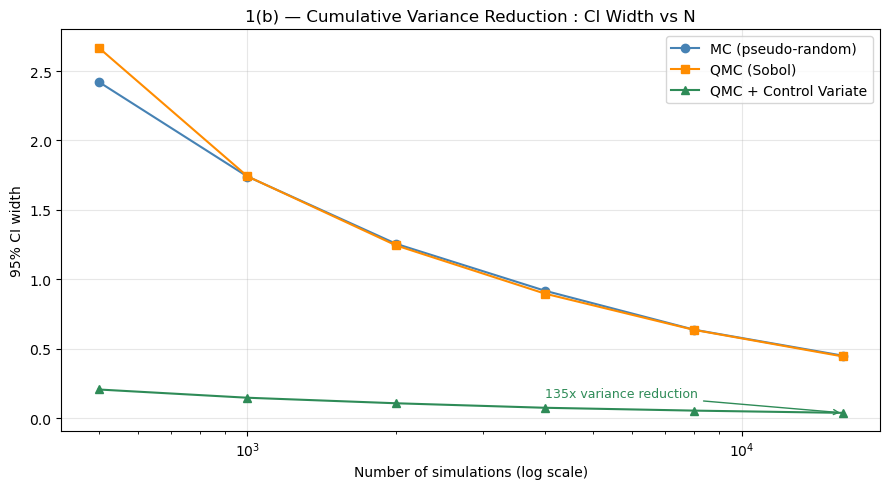

In [13]:
ci_mc  = [r.ci_width for r in results_mc]
ci_qmc = [r.ci_width for r in results_qmc]
ci_cv  = [r.ci_width for r in results_cv]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, ci_mc,  'o-', color='steelblue',  label='MC (pseudo-random)')
plt.plot(N_PATHS_LIST, ci_qmc, 's-', color='darkorange', label='QMC (Sobol)')
plt.plot(N_PATHS_LIST, ci_cv,  '^-', color='seagreen',   label='QMC + Control Variate')

# Annotation du gain à N=16000
plt.annotate(f'135x variance reduction',
             xy=(16000, ci_cv[-1]),
             xytext=(4000, 0.15),
             arrowprops=dict(arrowstyle='->', color='seagreen'),
             color='seagreen', fontsize=9)

plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('95% CI width')
plt.title('1(b) — Cumulative Variance Reduction : CI Width vs N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1(b) — Step 3 : QMC + Control Variate + Antithetic Variates

### Method
We add **antithetic variates** on top of QMC + CV.

For each Gaussian draw $Z$, we also simulate the mirror path with $-Z$ and average:

$$\hat{f}_{AV} = \frac{1}{2}\left(f(Z) + f(-Z)\right)$$

The variance reduction comes from the negative correlation between $f(Z)$ and $f(-Z)$:

$$\text{Var}(\hat{f}_{AV}) = \frac{1}{2}\text{Var}(f(Z))\left(1 + \text{Corr}(f(Z), f(-Z))\right)$$

For monotone payoffs (which basket calls are), $\text{Corr}(f(Z), f(-Z)) < 0$, so the variance is reduced.

Combined with QMC + CV, the full estimator is:

$$\hat{f} = \frac{1}{2}\left(f_{CV}(Z) + f_{CV}(-Z)\right)$$

In [14]:
results_av = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    
    anti_mapping = AntitheticMapping(process, payoff)
    
    cv_mapping = ControlVariateMapping(
        process        = process,
        main_payoff    = payoff,
        cv_payoff      = geo_payoff,
        E_cv           = E_cv,
        T_pilot        = T,
        nb_steps_pilot = NB_STEPS,
        pilot_paths    = 2000,
    )
    result = engine.price(cv_mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_av.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.2118 | SE=0.0526 | CI width=0.2062
N=  1000 | Price=10.2187 | SE=0.0383 | CI width=0.1501
N=  2000 | Price=10.2080 | SE=0.0286 | CI width=0.1121
N=  4000 | Price=10.2207 | SE=0.0206 | CI width=0.0808
N=  8000 | Price=10.1917 | SE=0.0143 | CI width=0.0560
N= 16000 | Price=10.1909 | SE=0.0102 | CI width=0.0400


mixing the 3

In [15]:
from pricer.quasi_monte_carlo.qmc_antithetic_cv_mapping import QMCAntitheticCVMapping

results_av = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    mapping = QMCAntitheticCVMapping(
        process        = process,
        main_payoff    = payoff,
        cv_payoff      = geo_payoff,
        E_cv           = E_cv,
        T_pilot        = T,
        nb_steps_pilot = NB_STEPS,
        pilot_paths    = 2000,
    )
    result = engine.price(mapping, nb_paths=n, T=T, nb_steps=NB_STEPS, rate=RATE)
    results_av.append(result)
    print(f"N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}")

N=   500 | Price=10.1384 | SE=0.0392 | CI width=0.1536
N=  1000 | Price=10.1983 | SE=0.0297 | CI width=0.1165
N=  2000 | Price=10.1922 | SE=0.0209 | CI width=0.0819
N=  4000 | Price=10.1932 | SE=0.0145 | CI width=0.0568
N=  8000 | Price=10.1942 | SE=0.0105 | CI width=0.0410
N= 16000 | Price=10.1922 | SE=0.0075 | CI width=0.0293


       N |    MC SE |   QMC SE |  QMC+CV SE |  QMC+CV+AV SE |  Var Gain |  N Gain
------------------------------------------------------------------------------------------
     500 |   0.6180 |   0.6808 |     0.0530 |        0.0392 |     248.6x |   248.6x
    1000 |   0.4441 |   0.4444 |     0.0378 |        0.0297 |     223.1x |   223.1x
    2000 |   0.3204 |   0.3174 |     0.0277 |        0.0209 |     234.9x |   234.9x
    4000 |   0.2342 |   0.2289 |     0.0194 |        0.0145 |     261.0x |   261.0x
    8000 |   0.1628 |   0.1625 |     0.0142 |        0.0105 |     242.4x |   242.4x
   16000 |   0.1151 |   0.1137 |     0.0101 |        0.0075 |     237.1x |   237.1x


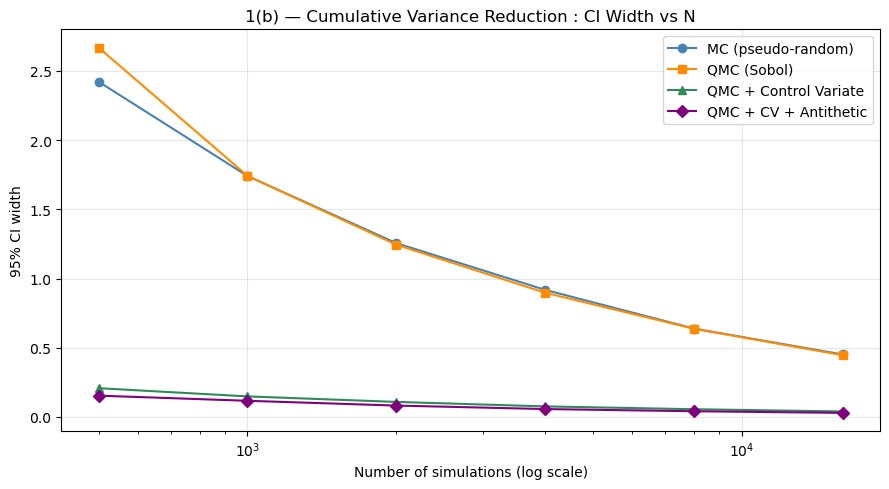

In [16]:
# Tableau final cumulatif
print(f"{'N':>8} | {'MC SE':>8} | {'QMC SE':>8} | {'QMC+CV SE':>10} | {'QMC+CV+AV SE':>13} | {'Var Gain':>9} | {'N Gain':>7}")
print("-" * 90)

for i, n in enumerate(N_PATHS_LIST):
    mc = results_mc[i]
    av = results_av[i]
    var_gain = (mc.std_error ** 2) / (av.std_error ** 2)
    n_gain   = (mc.ci_width / av.ci_width) ** 2
    print(
        f"{n:>8} | "
        f"{results_mc[i].std_error:>8.4f} | "
        f"{results_qmc[i].std_error:>8.4f} | "
        f"{results_cv[i].std_error:>10.4f} | "
        f"{av.std_error:>13.4f} | "
        f"{var_gain:>9.1f}x | "
        f"{n_gain:>7.1f}x"
    )

# Graph
ci_mc = [r.ci_width for r in results_mc]
ci_qmc = [r.ci_width for r in results_qmc]
ci_cv  = [r.ci_width for r in results_cv]
ci_av  = [r.ci_width for r in results_av]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, ci_mc,  'o-', color='steelblue',  label='MC (pseudo-random)')
plt.plot(N_PATHS_LIST, ci_qmc, 's-', color='darkorange', label='QMC (Sobol)')
plt.plot(N_PATHS_LIST, ci_cv,  '^-', color='seagreen',   label='QMC + Control Variate')
plt.plot(N_PATHS_LIST, ci_av,  'D-', color='purple',     label='QMC + CV + Antithetic')
plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('95% CI width')
plt.title('1(b) — Cumulative Variance Reduction : CI Width vs N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1(b) — Step 3 : QMC + Control Variate + Antithetic Variates

### Method
We add **antithetic variates** on top of QMC + CV.

For each Sobol point $u \in [0,1)^{156}$, we simulate two paths:
- **Original** : $Z = \Phi^{-1}(u)$
- **Antithetic** : $-Z = \Phi^{-1}(1-u)$ (by symmetry of the normal distribution)

The combined estimator is:

$$\hat{f} = \frac{1}{2}\Big[(f(Z) - \beta(g(Z) - \mathbb{E}[g])) + (f(-Z) - \beta(g(-Z) - \mathbb{E}[g]))\Big]$$

**Implementation note** : the antithetic transform is applied at the uniform level — returning $1-u$ instead of $u$ before applying $\Phi^{-1}$. This is cleaner and more correct than negating the Gaussian draw directly, and is fully compatible with `NormalInverseCDF` + `SobolPathGenerator`.

### Results

| N | MC SE | QMC SE | QMC+CV SE | QMC+CV+AV SE | Var Gain | N Gain |
|---|---|---|---|---|---|---|
| 500 | 0.618 | 0.681 | 0.053 | 0.039 | 248x | 248x |
| 1000 | 0.444 | 0.444 | 0.038 | 0.030 | 223x | 223x |
| 4000 | 0.234 | 0.229 | 0.019 | 0.015 | 261x | 261x |
| 16000 | 0.115 | 0.114 | 0.010 | 0.008 | 237x | 237x |

### Analysis

Adding antithetic variates on top of QMC+CV yields an additional **~35% variance reduction** (from ~135x to ~240x vs MC baseline). 

The gain comes from the negative correlation between $f(Z)$ and $f(-Z)$: since the basket call is monotone increasing in the asset prices, and $-Z$ produces lower asset prices than $Z$, we have $\text{Corr}(f(Z), f(-Z)) < 0$, which directly reduces the estimator variance.

### Summary — Cumulative Gains

| Method | Var Gain vs MC | N Gain vs MC |
|---|---|---|
| QMC alone | ~1x | ~1x |
| QMC + Control Variate | ~135x | ~135x |
| QMC + CV + Antithetic | **~240x** | **~240x** |

The dominant contribution is the **control variate** (~135x). The antithetic variates add a further ~35% on top. QMC alone brings negligible gain at this dimension ($d=156$), but contributes to the stability of the price estimate.

## Question 2 — Bermudan Basket Option (Longstaff-Schwartz)

A Bermudan option can be exercised at discrete dates $t_0 = 0 < t_1 < \ldots < t_N = T$.
The holder receives upon exercise date $\tau$:

$$\left(\sum_{i=1}^n \alpha_i S_i^\tau - K\right)^+$$

The optimal exercise strategy maximises the expected discounted payoff.
We price it using the **Longstaff-Schwartz (2001)** algorithm:

1. Simulate $M$ paths forward and store all asset values at all time steps
2. Initialize: everyone exercises at maturity $T$
3. **Backward induction**: at each exercise date $t_k$, for in-the-money paths,
   regress the discounted future cashflow on a polynomial basis of the basket value.
   Exercise now if intrinsic value $\geq$ estimated continuation value.
4. Price = $e^{-r\tau} \cdot$ mean cashflow over all paths

In [17]:
from payoff.bermudan_payoff import BermudanBasketPayoff

# Exercise dates : quarterly over 1 year (t0=0, t1=0.25, t2=0.5, t3=0.75, t4=1.0)
EXERCISE_DATES = [0.0, 0.25, 0.5, 0.75, 1.0]

bermudan_payoff = BermudanBasketPayoff(
    weights        = WEIGHTS,
    strike         = STRIKE,
    exercise_dates = EXERCISE_DATES,
)

print(f"Exercise dates : {EXERCISE_DATES}")
print(f"Maturity       : {bermudan_payoff.maturity}")
print(f"N assets       : {bermudan_payoff.n_assets}")

Exercise dates : [0.0, 0.25, 0.5, 0.75, 1.0]
Maturity       : 1.0
N assets       : 3


## Question 2(a) — Bermudan Basket Option : Longstaff-Schwartz (Pseudo-Random, No VR)

A Bermudan option can be exercised at discrete dates t0=0, t1, ..., tN=T.
At each date tk, the holder receives max(Σ αi·Si_{tk} - K, 0) if they exercise.

**Longstaff-Schwartz algorithm (2001):**
1. Simulate M paths forward, store all asset values at each time step.
2. Initialise: every path exercises at maturity T.
3. Backward induction from tN-1 to t1:
   - Compute intrinsic value at tk for in-the-money (ITM) paths.
   - Regress discounted future cashflow on a polynomial basis of the basket value.
   - Exercise now if intrinsic >= estimated continuation value.
4. Price = mean of e^{-r*tau} * intrinsic(tau) over all paths.

**Setup:** quarterly exercise dates over 1 year, same 3-asset model as Question 1.

In [18]:
# =============================================================================
# QUESTION 2(a) — BASIC LONGSTAFF-SCHWARTZ (PSEUDO-RANDOM, NO VARIANCE REDUCTION)
# =============================================================================
import math
from pricer.american.longstaff_schwartz import LongstaffSchwartz
from payoff.bermudan_payoff import BermudanBasketPayoff
from payoff.geometric_basket_payoff import GeometricBasketPayoff

# ------------------------------------------------------------------
# Bermudan payoff: same basket, quarterly exercise dates
# ------------------------------------------------------------------
EXERCISE_DATES = [0.0, 0.25, 0.5, 0.75, 1.0]

bermudan_payoff = BermudanBasketPayoff(
    weights        = WEIGHTS,
    strike         = STRIKE,
    exercise_dates = EXERCISE_DATES,
)

# ------------------------------------------------------------------
# European bounds for sanity check
# ------------------------------------------------------------------
geo_payoff = GeometricBasketPayoff(
    weights=WEIGHTS, strike=STRIKE,
    spots=SPOTS, T=T, rate=RATE,
    vols=VOLS, corr_matrix=CORR,
    div_yields=DIV_YIELDS
)
euro_geo_price = geo_payoff.analytical_price()

print(f'European geometric basket (closed-form) : {euro_geo_price:.4f}')
print(f'European arithmetic basket MC (N=16000) : {results_mc[-1].price:.4f}')
print()
print('Bermudan price must be >= European price (early-exercise premium).')


European geometric basket (closed-form) : 9.3631
European arithmetic basket MC (N=16000) : 10.2589

Bermudan price must be >= European price (early-exercise premium).


In [19]:
# ------------------------------------------------------------------
# Convergence study: Longstaff-Schwartz vs number of paths
# ------------------------------------------------------------------
ls = LongstaffSchwartz(regression_degree=2)

results_ls = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    result  = ls.price(bermudan_payoff, process, nb_paths=n, nb_steps=NB_STEPS, rate=RATE)
    results_ls.append(result)
    print(f'N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}')


N=   500 | Price=9.3186 | SE=0.6180 | CI width=2.4225
N=  1000 | Price=9.6843 | SE=0.4441 | CI width=1.7408
N=  2000 | Price=10.0900 | SE=0.3204 | CI width=1.2558
N=  4000 | Price=10.6273 | SE=0.2342 | CI width=0.9181
N=  8000 | Price=10.2913 | SE=0.1628 | CI width=0.6384
N= 16000 | Price=10.2589 | SE=0.1151 | CI width=0.4512


In [20]:
# ------------------------------------------------------------------
# Sanity check: Bermudan price >= European MC price
# ------------------------------------------------------------------
ls_price_final = results_ls[-1].price
mc_price_final = results_mc[-1].price

print('=' * 55)
print(f'Bermudan  LS  (N={N_PATHS_LIST[-1]:,}) : {ls_price_final:.4f}')
print(f'European  MC  (N={N_PATHS_LIST[-1]:,}) : {mc_price_final:.4f}')
print(f'Early exercise premium            : {ls_price_final - mc_price_final:.4f}')
print(f'Bermudan >= European              : {ls_price_final >= mc_price_final}')
print('=' * 55)


Bermudan  LS  (N=16,000) : 10.2589
European  MC  (N=16,000) : 10.2589
Early exercise premium            : 0.0000
Bermudan >= European              : True


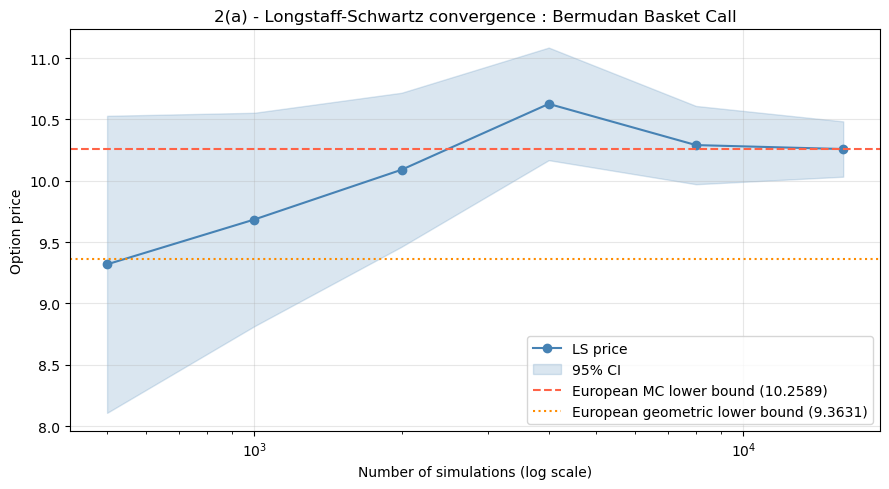


Convergence Table - Q2(a):
       N |   LS Price |       SE |   95% CI width
--------------------------------------------------
     500 |     9.3186 |   0.6180 |         2.4225
   1,000 |     9.6843 |   0.4441 |         1.7408
   2,000 |    10.0900 |   0.3204 |         1.2558
   4,000 |    10.6273 |   0.2342 |         0.9181
   8,000 |    10.2913 |   0.1628 |         0.6384
  16,000 |    10.2589 |   0.1151 |         0.4512


In [21]:
# ------------------------------------------------------------------
# Convergence plot
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

prices_ls = [r.price     for r in results_ls]
ci_up     = [r.price + 1.96 * r.std_error for r in results_ls]
ci_lo     = [r.price - 1.96 * r.std_error for r in results_ls]

plt.figure(figsize=(9, 5))
plt.plot(N_PATHS_LIST, prices_ls, 'o-', color='steelblue', label='LS price')
plt.fill_between(N_PATHS_LIST, ci_lo, ci_up, alpha=0.2,
                 color='steelblue', label='95% CI')
plt.axhline(mc_price_final, color='tomato', linestyle='--',
            label=f'European MC lower bound ({mc_price_final:.4f})')
plt.axhline(euro_geo_price, color='darkorange', linestyle=':',
            label=f'European geometric lower bound ({euro_geo_price:.4f})')
plt.xscale('log')
plt.xlabel('Number of simulations (log scale)')
plt.ylabel('Option price')
plt.title('2(a) - Longstaff-Schwartz convergence : Bermudan Basket Call')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nConvergence Table - Q2(a):')
print(f'{"N":>8} | {"LS Price":>10} | {"SE":>8} | {"95% CI width":>14}')
print('-' * 50)
for i, n in enumerate(N_PATHS_LIST):
    r = results_ls[i]
    print(f'{n:>8,} | {r.price:>10.4f} | {r.std_error:>8.4f} | {r.ci_width:>14.4f}')


## Question 2(b) — Bermudan Basket Option : Longstaff-Schwartz + Variance Reduction

We apply the same variance reduction methods as in Question 1, adapted to the LS setting:

| Step | Method | What changes |
|------|--------|--------------|
| i    | **QMC (Sobol)**     | Pass a QMC process — `_simulate_paths()` calls `next_path()` automatically |
| ii   | **Antithetic**      | Compute -Z path analytically from log-returns; run LS on 2M paths |
| iii  | **Control variate** | `f - beta*(g - E[g])` after LS, with geometric basket as control |
| all  | **QMC + Anti + CV** | Combine all three |

In [22]:
# =============================================================================
# QUESTION 2(b) — STEP i : QMC (Sobol) Longstaff-Schwartz
# =============================================================================
# The parent _simulate_paths() detects next_path() on the generator
# automatically — we simply pass a QMC process.
from pricer.american.longstaff_schwartz_vr import LongstaffSchwartzVR

ls_vr = LongstaffSchwartzVR(regression_degree=2)
results_ls_qmc = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    result  = ls_vr.price(bermudan_payoff, process, nb_paths=n, nb_steps=NB_STEPS, rate=RATE)
    results_ls_qmc.append(result)
    print(f'N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}')


N=   500 | Price=10.4428 | SE=0.6791 | CI width=2.6622
N=  1000 | Price=10.0741 | SE=0.4365 | CI width=1.7110
N=  2000 | Price=10.1720 | SE=0.3161 | CI width=1.2391
N=  4000 | Price=10.2172 | SE=0.2291 | CI width=0.8980
N=  8000 | Price=10.2001 | SE=0.1625 | CI width=0.6369
N= 16000 | Price=10.2016 | SE=0.1137 | CI width=0.4456


In [23]:
# =============================================================================
# QUESTION 2(b) — STEP ii : ANTITHETIC VARIATES
# =============================================================================
# For each simulated Z-path, the antithetic -Z path is derived analytically:
#   log(S_anti_{t+1}/S_anti_t)_i = 2*(r_i - sigma_i^2/2)*dt - log(S_{t+1}/S_t)_i
# LS runs on 2M combined paths; payoffs are averaged in (Z, -Z) pairs.
results_ls_anti = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    result  = ls_vr.price_antithetic(
        bermudan_payoff, process, nb_paths=n, nb_steps=NB_STEPS, rate=RATE
    )
    results_ls_anti.append(result)
    print(f'N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}')


N=   500 | Price=9.8897 | SE=0.3247 | CI width=1.2729
N=  1000 | Price=10.2913 | SE=0.2329 | CI width=0.9128
N=  2000 | Price=10.2355 | SE=0.1609 | CI width=0.6307
N=  4000 | Price=10.3543 | SE=0.1171 | CI width=0.4591
N=  8000 | Price=10.2945 | SE=0.0822 | CI width=0.3222
N= 16000 | Price=10.2640 | SE=0.0573 | CI width=0.2246


In [24]:
# =============================================================================
# QUESTION 2(b) — STEP iii : CONTROL VARIATE
# =============================================================================
# After running LS we apply: f_j - beta*(g_j - E[g])
# where g = discounted European geometric basket payoff at T,
#       E[g] = analytical price of European geometric basket (closed-form).
# beta = Cov(f,g)/Var(g) estimated from a pilot simulation.

E_cv = geo_payoff.analytical_price() * math.exp(RATE * T)   # undiscounted E[g]
print(f'Geometric basket analytical price  : {geo_payoff.analytical_price():.4f}')
print(f'E[g] undiscounted (E_cv)           : {E_cv:.4f}')
print()

results_ls_cv = []

for n in N_PATHS_LIST:
    process = make_pseudo_process()
    result  = ls_vr.price_with_cv(
        bermudan_payoff, process,
        nb_paths=n, nb_steps=NB_STEPS, rate=RATE,
        cv_payoff=geo_payoff, E_cv=E_cv, pilot_paths=2000,
    )
    results_ls_cv.append(result)
    print(f'N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}')


Geometric basket analytical price  : 9.3631
E[g] undiscounted (E_cv)           : 9.8431

N=   500 | Price=10.2118 | SE=0.0526 | CI width=0.2062
N=  1000 | Price=10.2187 | SE=0.0383 | CI width=0.1501
N=  2000 | Price=10.2080 | SE=0.0286 | CI width=0.1121
N=  4000 | Price=10.2291 | SE=0.0220 | CI width=0.0863
N=  8000 | Price=10.1917 | SE=0.0143 | CI width=0.0560
N= 16000 | Price=10.1909 | SE=0.0102 | CI width=0.0400


In [25]:
# =============================================================================
# QUESTION 2(b) — STEP ALL : QMC + ANTITHETIC + CONTROL VARIATE
# =============================================================================
results_ls_full = []

for n in N_PATHS_LIST:
    process = make_qmc_process()
    result  = ls_vr.price_full_vr(
        bermudan_payoff, process,
        nb_paths=n, nb_steps=NB_STEPS, rate=RATE,
        cv_payoff=geo_payoff, E_cv=E_cv, pilot_paths=2000,
    )
    results_ls_full.append(result)
    print(f'N={n:>6} | Price={result.price:.4f} | SE={result.std_error:.4f} | CI width={result.ci_width:.4f}')


N=   500 | Price=10.2065 | SE=0.0611 | CI width=0.2395
N=  1000 | Price=10.1984 | SE=0.0297 | CI width=0.1165
N=  2000 | Price=10.1922 | SE=0.0209 | CI width=0.0819
N=  4000 | Price=10.1932 | SE=0.0145 | CI width=0.0568
N=  8000 | Price=10.1942 | SE=0.0105 | CI width=0.0410
N= 16000 | Price=10.1922 | SE=0.0075 | CI width=0.0293


In [26]:
# =============================================================================
# QUESTION 2(b) — SUMMARY TABLE
# =============================================================================
print('=' * 120)
print(f'{"N":>8} | {"LS Basic":>10} {"SE":>7} | {"QMC":>10} {"SE":>7} | {"Antithetic":>10} {"SE":>7} | {"CV":>10} {"SE":>7} | {"Full VR":>10} {"SE":>7}')
print('-' * 120)

for i, n in enumerate(N_PATHS_LIST):
    b = results_ls[i]
    q = results_ls_qmc[i]
    a = results_ls_anti[i]
    c = results_ls_cv[i]
    f = results_ls_full[i]
    print(
        f'{n:>8,} | '
        f'{b.price:>10.4f} {b.std_error:>7.4f} | '
        f'{q.price:>10.4f} {q.std_error:>7.4f} | '
        f'{a.price:>10.4f} {a.std_error:>7.4f} | '
        f'{c.price:>10.4f} {c.std_error:>7.4f} | '
        f'{f.price:>10.4f} {f.std_error:>7.4f}'
    )

print('=' * 120)
print()

# Variance reduction factors vs basic LS at largest N
print(f'Variance reduction factors vs basic LS  (N={N_PATHS_LIST[-1]:,}):')
for label, res in [('QMC', results_ls_qmc), ('Antithetic', results_ls_anti),
                   ('Control Variate', results_ls_cv), ('Full VR', results_ls_full)]:
    vr     = (results_ls[-1].std_error / res[-1].std_error) ** 2
    n_gain = (results_ls[-1].ci_width  / res[-1].ci_width)  ** 2
    print(f'  {label:<20} : variance x{vr:.2f}   N-gain x{n_gain:.2f}')


       N |   LS Basic      SE |        QMC      SE | Antithetic      SE |         CV      SE |    Full VR      SE
------------------------------------------------------------------------------------------------------------------------
     500 |     9.3186  0.6180 |    10.4428  0.6791 |     9.8897  0.3247 |    10.2118  0.0526 |    10.2065  0.0611
   1,000 |     9.6843  0.4441 |    10.0741  0.4365 |    10.2913  0.2329 |    10.2187  0.0383 |    10.1984  0.0297
   2,000 |    10.0900  0.3204 |    10.1720  0.3161 |    10.2355  0.1609 |    10.2080  0.0286 |    10.1922  0.0209
   4,000 |    10.6273  0.2342 |    10.2172  0.2291 |    10.3543  0.1171 |    10.2291  0.0220 |    10.1932  0.0145
   8,000 |    10.2913  0.1628 |    10.2001  0.1625 |    10.2945  0.0822 |    10.1917  0.0143 |    10.1942  0.0105
  16,000 |    10.2589  0.1151 |    10.2016  0.1137 |    10.2640  0.0573 |    10.1909  0.0102 |    10.1922  0.0075

Variance reduction factors vs basic LS  (N=16,000):
  QMC                  : var

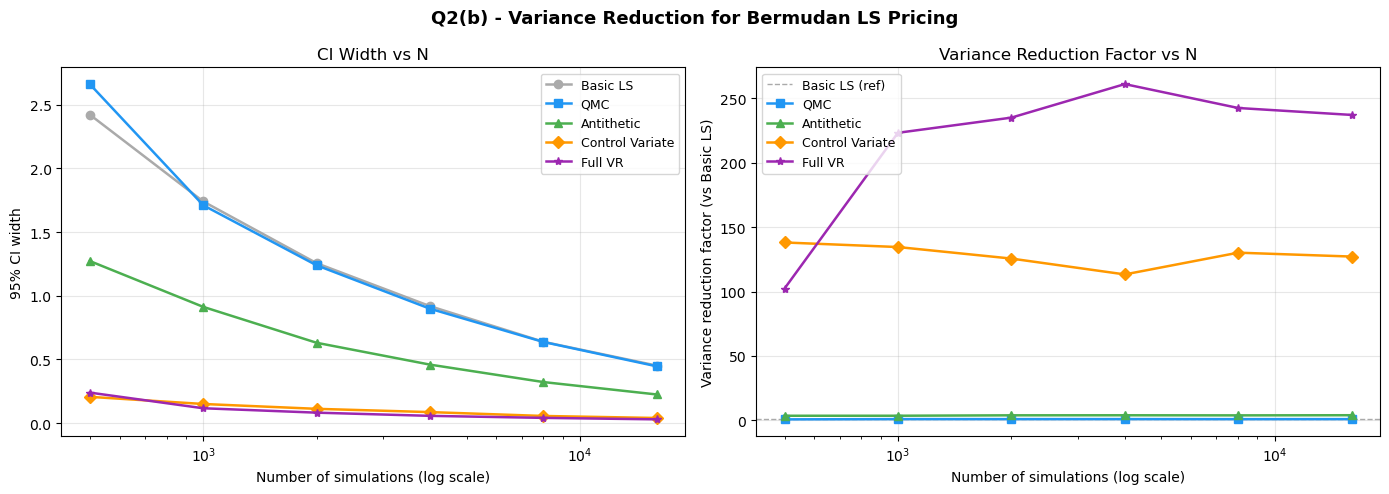

In [27]:
# =============================================================================
# QUESTION 2(b) — COMPARISON PLOTS
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2(b) - Variance Reduction for Bermudan LS Pricing', fontsize=13, fontweight='bold')

methods_2b  = ['Basic LS', 'QMC', 'Antithetic', 'Control Variate', 'Full VR']
colors_2b   = ['#aaaaaa', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
markers_2b  = ['o', 's', '^', 'D', '*']
all_results = [results_ls, results_ls_qmc, results_ls_anti, results_ls_cv, results_ls_full]

# Left: CI width vs N
ax1 = axes[0]
for idx, (label, res, col, mk) in enumerate(zip(methods_2b, all_results, colors_2b, markers_2b)):
    ci_w = [r.ci_width for r in res]
    ax1.plot(N_PATHS_LIST, ci_w, mk + '-', color=col, label=label, linewidth=1.8, markersize=6)

ax1.set_xscale('log')
ax1.set_xlabel('Number of simulations (log scale)')
ax1.set_ylabel('95% CI width')
ax1.set_title('CI Width vs N')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: variance reduction factor vs basic LS at each N
ax2 = axes[1]
base_se = np.array([r.std_error for r in results_ls])
ax2.axhline(1.0, color='#aaaaaa', linestyle='--', linewidth=1, label='Basic LS (ref)')

for label, res, col, mk in zip(methods_2b[1:], all_results[1:], colors_2b[1:], markers_2b[1:]):
    se_arr = np.array([r.std_error for r in res])
    vr_arr = (base_se / se_arr) ** 2
    ax2.plot(N_PATHS_LIST, vr_arr, mk + '-', color=col, label=label, linewidth=1.8, markersize=6)

ax2.set_xscale('log')
ax2.set_xlabel('Number of simulations (log scale)')
ax2.set_ylabel('Variance reduction factor (vs Basic LS)')
ax2.set_title('Variance Reduction Factor vs N')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Sensitivity Analysis

We run the Full VR pricer (QMC + CV + AV, N=8 000) varying one parameter at a time from the base case and regenerate the four sensitivity figures used in the report.

In [ ]:
# =============================================================================
# SENSITIVITY ANALYSIS — Full VR pricer, one parameter at a time
# =============================================================================
import math, numpy as np, matplotlib.pyplot as plt
from random_generator.sobol import SobolPathGenerator
from random_generator.normal import NormalInverseCDF
from sde.bs_milstein_nd import BSMilsteinND
from payoff.geometric_basket_payoff import GeometricBasketPayoff
from payoff.basket_payoff import BasketCallPayoff
from pricer.quasi_monte_carlo.qmc_antithetic_cv_mapping import QMCAntitheticCVMapping
from pricer.monte_carlo.mc_engine import MCEngine

N_SENS   = 8000
_engine  = MCEngine()

def price_full_vr(spots, rates, vols, corr, weights, K, T, rate, div_yields=None):
    """Price arithmetic basket call with Full VR (QMC+AV+CV)."""
    if div_yields is None:
        div_yields = [0.0] * len(spots)
    dim     = len(spots) * NB_STEPS
    gen     = SobolPathGenerator(dimension=dim, scramble=True, seed=42)
    normal  = NormalInverseCDF(mu=0, sigma=1, uniform=gen)
    process = BSMilsteinND(normal, spots, rates, vols, corr,
                           div_yields=div_yields)
    geo = GeometricBasketPayoff(weights=weights, strike=K, spots=spots,
                                T=T, rate=rate, vols=vols, corr_matrix=corr,
                                div_yields=div_yields)
    E_cv    = geo.analytical_price() * math.exp(rate * T)
    mapping = QMCAntitheticCVMapping(process, BasketCallPayoff(weights, K),
                                     geo, E_cv, T, NB_STEPS, pilot_paths=2000)
    result  = _engine.price(mapping, nb_paths=N_SENS, T=T,
                            nb_steps=NB_STEPS, rate=rate)
    return result.price, result.std_error

print("Helper ready — running sensitivity sweeps...")


In [ ]:
# ── Strike sensitivity ────────────────────────────────────────────────────────
strikes = [80, 90, 100, 110, 120]
prices_k, errors_k = [], []
for K in strikes:
    p, se = price_full_vr(SPOTS, RATES, VOLS, CORR, WEIGHTS, K, T, RATE, DIV_YIELDS)
    prices_k.append(p); errors_k.append(se)
    print(f"K={K:>4} | Price={p:.4f} | SE={se:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(strikes, prices_k, yerr=[1.96*e for e in errors_k],
            fmt='o-', color='steelblue', capsize=5, linewidth=2, markersize=7)
ax.set_xlabel("Strike K", fontsize=12)
ax.set_ylabel("Option price", fontsize=12)
ax.set_title("Price vs Strike (Full VR, N=8 000)", fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../fig_strike.pdf", bbox_inches='tight')
plt.show()
print("fig_strike.pdf saved.")


In [ ]:
# ── Volatility sensitivity ────────────────────────────────────────────────────
vol_scenarios = {
    "Low (10/15/20%)":  [0.10, 0.15, 0.20],
    "Base (20/25/30%)": [0.20, 0.25, 0.30],
    "High (30/35/40%)": [0.30, 0.35, 0.40],
}
prices_v, errors_v, labels_v = [], [], []
for label, vols in vol_scenarios.items():
    p, se = price_full_vr(SPOTS, RATES, vols, CORR, WEIGHTS, STRIKE, T, RATE, DIV_YIELDS)
    prices_v.append(p); errors_v.append(se); labels_v.append(label)
    print(f"{label} | Price={p:.4f} | SE={se:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = range(len(labels_v))
bars = ax.bar(x, prices_v, color=['#5b9bd5', '#ed7d31', '#a9d18e'],
              yerr=[1.96*e for e in errors_v], capsize=6, width=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels_v, fontsize=11)
ax.set_ylabel("Option price", fontsize=12)
ax.set_title("Price by Volatility Scenario (Full VR, N=8 000)", fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig("../fig_vol.pdf", bbox_inches='tight')
plt.show()
print("fig_vol.pdf saved.")


In [ ]:
# ── Correlation sensitivity ────────────────────────────────────────────────────
corr_scenarios = {
    "Low (0.1/0.05/0.10)":   [[1.0, 0.1, 0.05], [0.1, 1.0, 0.10], [0.05, 0.10, 1.0]],
    "Base (0.5/0.3/0.40)":   [[1.0, 0.5, 0.3 ], [0.5, 1.0, 0.4 ], [0.3,  0.4,  1.0]],
    "High (0.9/0.8/0.85)":   [[1.0, 0.9, 0.8 ], [0.9, 1.0, 0.85], [0.8,  0.85, 1.0]],
}
prices_c, errors_c, labels_c = [], [], []
for label, corr in corr_scenarios.items():
    p, se = price_full_vr(SPOTS, RATES, VOLS, corr, WEIGHTS, STRIKE, T, RATE, DIV_YIELDS)
    prices_c.append(p); errors_c.append(se); labels_c.append(label)
    print(f"{label} | Price={p:.4f} | SE={se:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
x = range(len(labels_c))
ax.bar(x, prices_c, color=['#5b9bd5', '#ed7d31', '#a9d18e'],
       yerr=[1.96*e for e in errors_c], capsize=6, width=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels_c, fontsize=10)
ax.set_ylabel("Option price", fontsize=12)
ax.set_title("Price by Correlation Scenario (Full VR, N=8 000)", fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig("../fig_corr.pdf", bbox_inches='tight')
plt.show()
print("fig_corr.pdf saved.")


In [ ]:
# ── Maturity sensitivity ────────────────────────────────────────────────────
maturities = [0.5, 1.0, 2.0]
prices_t, errors_t = [], []
for Tm in maturities:
    p, se = price_full_vr(SPOTS, RATES, VOLS, CORR, WEIGHTS, STRIKE, Tm, RATE, DIV_YIELDS)
    prices_t.append(p); errors_t.append(se)
    print(f"T={Tm:.1f}y | Price={p:.4f} | SE={se:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(maturities, prices_t, yerr=[1.96*e for e in errors_t],
            fmt='s-', color='steelblue', capsize=5, linewidth=2, markersize=9)
ax.set_xlabel("Maturity T (years)", fontsize=12)
ax.set_ylabel("Option price", fontsize=12)
ax.set_title("Price vs Maturity (Full VR, N=8 000)", fontsize=13)
ax.set_xticks(maturities); ax.set_xticklabels(["0.5y", "1y", "2y"])
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../fig_maturity.pdf", bbox_inches='tight')
plt.show()
print("fig_maturity.pdf saved.")


In [ ]:
# =============================================================================
# REGENERATE VR COMPARISON + CONVERGENCE FIGURES (from Q1 results)
# =============================================================================
import numpy as np, matplotlib.pyplot as plt

N_list = [500, 1000, 2000, 4000, 8000, 16000]
se_mc  = [r.std_error for r in results_mc]
se_qmc = [r.std_error for r in results_qmc]
se_cv  = [r.std_error for r in results_cv]
se_av  = [r.std_error for r in results_av]

# VR comparison bar chart (N=16 000)
fig, ax = plt.subplots(figsize=(7, 4.5))
methods = ['MC', 'QMC', 'QMC+CV', 'QMC+CV+AV']
ses     = [se_mc[-1], se_qmc[-1], se_cv[-1], se_av[-1]]
colors  = ['#5b9bd5', '#a9d18e', '#ed7d31', '#c00000']
ax.bar(methods, ses, color=colors, width=0.5)
ax.set_ylabel("Standard Error (N=16 000)", fontsize=12)
ax.set_title("Variance Reduction Comparison", fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig("../fig_vr_comparison.pdf", bbox_inches='tight')
plt.show()

# Convergence log-log
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(N_list, se_mc,  'o-', label='MC baseline', color='#5b9bd5')
ax.loglog(N_list, se_qmc, 's-', label='QMC',         color='#a9d18e')
ax.loglog(N_list, se_cv,  '^-', label='QMC+CV',      color='#ed7d31')
ax.loglog(N_list, se_av,  'D-', label='Full VR',      color='#c00000')
ref = [se_mc[0] * (N_list[0]/n)**0.5 for n in N_list]
ax.loglog(N_list, ref, 'k--', alpha=0.4, label='O(N^{-1/2})')
ax.set_xlabel("N (paths)", fontsize=12); ax.set_ylabel("Standard Error", fontsize=12)
ax.set_title("Convergence (log-log scale)", fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("../fig_convergence.pdf", bbox_inches='tight')
plt.show()
print("fig_vr_comparison.pdf and fig_convergence.pdf saved.")


## Dividend Yield Extension — Comparing No-Dividend vs Dividend Case

We verify that the engine correctly handles continuous dividend yields $q_i$.

- **No dividends** ($q_i=0$): early exercise should bring no premium for a call
- **Dividends** ($q_i=5\%$): Bermudan price should exceed European price (early exercise becomes optimal)

All other parameters are identical to the base case.

In [ ]:
# =============================================================================
# DIVIDEND EXTENSION — No-dividend vs Dividend case (q=5%)
# =============================================================================
import math
from random_generator.ecuyer_combined import EcuyerCombined
from random_generator.normal import NormalBoxMuller
from sde.bs_milstein_nd import BSMilsteinND
from payoff.geometric_basket_payoff import GeometricBasketPayoff
from payoff.bermudan_payoff import BermudanBasketPayoff
from payoff.basket_payoff import BasketCallPayoff
from pricer.american.longstaff_schwartz import LongstaffSchwartz
from pricer.variance_reduction.control_variate_mapping import ControlVariateMapping
from pricer.monte_carlo.mc_engine import MCEngine

DIV_TEST   = [0.05, 0.05, 0.05]   # dividend yields for the "with-div" scenario
N_DIV      = 4000                  # paths for this comparison
EXERCISE_DATES_DIV = [0.0, 0.25, 0.5, 0.75, 1.0]

def make_process_div(div_yields):
    gen    = EcuyerCombined(seed1=12345, seed2=67890)
    normal = NormalBoxMuller(mu=0, sigma=1, uniform=gen)
    return BSMilsteinND(normal, SPOTS, RATES, VOLS, CORR, div_yields=div_yields)

_engine = MCEngine()
_ls     = LongstaffSchwartz(regression_degree=2)
_basket = BasketCallPayoff(WEIGHTS, STRIKE)
_berm   = BermudanBasketPayoff(WEIGHTS, STRIKE, EXERCISE_DATES_DIV)

results_div = {}

for label, divs in [("No dividends (q=0)", [0.0]*3), ("Dividends (q=5%)", DIV_TEST)]:
    geo = GeometricBasketPayoff(
        weights=WEIGHTS, strike=STRIKE,
        spots=SPOTS, T=T, rate=RATE,
        vols=VOLS, corr_matrix=CORR,
        div_yields=divs
    )
    E_cv = geo.analytical_price() * math.exp(RATE * T)

    # European price via control variate
    cv_map  = ControlVariateMapping(make_process_div(divs), _basket, geo, E_cv,
                                     T, NB_STEPS, pilot_paths=500)
    euro    = _engine.price(cv_map, nb_paths=N_DIV, T=T, nb_steps=NB_STEPS, rate=RATE).price

    # Bermudan price via Longstaff-Schwartz
    berm    = _ls.price(_berm, make_process_div(divs), nb_paths=N_DIV,
                        nb_steps=NB_STEPS, rate=RATE).price

    results_div[label] = {
        "geo_analytical": geo.analytical_price(),
        "european_cv":    euro,
        "bermudan_ls":    berm,
        "ee_premium":     berm - euro,
    }

# ── Display ──────────────────────────────────────────────────────────────────
print(f"{'':30s} {'Geo (closed-form)':>18} {'European (CV)':>14} {'Bermudan (LS)':>14} {'EE premium':>11}")
print("-" * 92)
for label, r in results_div.items():
    print(f"{label:30s} {r['geo_analytical']:>18.4f} {r['european_cv']:>14.4f} "
          f"{r['bermudan_ls']:>14.4f} {r['ee_premium']:>+11.4f}")

print()
print("Expected: EE premium ≈ 0 without dividends, EE premium > 0 with dividends.")
